# P6 – Detección de Objetos | MyCobot 280
**Cinemática, Control y Visión de Robots – ROB 2026**

Detecta el cubo **amarillo** con OpenCV, calcula el centroide en píxeles,
transforma a mm en el sistema del robot y publica la posición para `main.py`.

| Entregable | Descripción |
|---|---|
| **P6.1** | Calibrar rangos HSV (Secciones 3, 5 y 6) |
| **P6.2** | Contorno + centroide (cx, cy) en píxeles |
| **P6.3** | Transformación píxel → mm |
| **P6.4** | Validación en ≥ 3 posiciones |
| **P6.5** | Robustez: falsos positivos, iluminación variable, objeto ausente |

`Puerto: /dev/ttyUSB0` | `Baud: 1_000_000` | `Robot: Yahboom MyCobot 280`

---
> **Flujo de uso:**  
> `Celda 0` → `Celda 1` → `Celda 2` → `Celda 3` → calibrar HSV (Sec. 5 ó 6) → validar (Sec. 9) → `get_object_position()` (Sec. 10)


## 0. Liberar cámara ⚠️ EJECUTAR SIEMPRE PRIMERO
Mata cualquier proceso que tenga ocupada `/dev/video0` y destruye ventanas OpenCV colgadas.

In [1]:
import subprocess, time, gc
try:
    import cv2
except ImportError:
    pass

# 1. Cerrar instancia cap previa si existe
try:
    cap.release()
    print('Instancia cap anterior liberada.')
except NameError:
    print('No habia cap abierta.')

# 2. Destruir ventanas OpenCV
try:
    cv2.destroyAllWindows()
except Exception:
    pass

# 3. Matar procesos que bloqueen la cámara
r = subprocess.run(
    'fuser /dev/video0 /dev/video1 2>/dev/null',
    shell=True, capture_output=True, text=True
)
pids = r.stdout.strip().split()
if pids:
    for pid in pids:
        subprocess.run(f'kill -9 {pid}', shell=True)
    print(f'Procesos eliminados: {pids}')
    time.sleep(1.5)
else:
    print('Camara libre, ningun proceso bloqueandola.')

gc.collect()
print('Listo para continuar.')


No habia cap abierta.
Camara libre, ningun proceso bloqueandola.
Listo para continuar.


## 1. Importaciones y conexión al robot

In [2]:
import cv2
import numpy as np
import time
import gc
import subprocess
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import ipywidgets as widgets

# API del robot
try:
    from pymycobot.mycobot import MyCobot
    mc = MyCobot('/dev/ttyUSB0', 1_000_000)
    mc.power_on()
    time.sleep(0.5)
    assert mc.is_controller_connected(), 'Robot no conectado'
    ROBOT_DISPONIBLE = True
    print('Robot conectado OK')
except Exception as e:
    print(f'Robot no disponible ({e}). Modo solo-vision.')
    mc = None
    ROBOT_DISPONIBLE = False

print(f'  OpenCV : {cv2.__version__}')
print(f'  NumPy  : {np.__version__}')


Robot conectado OK
  OpenCV : 4.10.0
  NumPy  : 1.23.5


## 2. Parámetros de calibración cámara ↔ robot

> **Cómo calibrar:**
> - `CAM_ORIGIN_X/Y_MM`: pon el cubo en el **centro óptico** (cx=320, cy=240) y lee `mc.get_coords()`.
> - `SCALE_X/Y_MM_PX`: mide cuántos píxeles ocupa un objeto de ancho conocido (ej. 50 mm). `SCALE = 50 / ancho_px`.


In [3]:
# RESOLUCIÓN
IMG_WIDTH  = 640
IMG_HEIGHT = 480

# ÍNDICE DE CÁMARA
CAM_INDEX = 0  # cambiar a 1 si /dev/video0 no es la correcta

# ORIGEN: posición del robot cuando el cubo está en el centro óptico
CAM_ORIGIN_X_MM = 150.0   # <-- ajustar en laboratorio con mc.get_coords()
CAM_ORIGIN_Y_MM =   0.0   # <-- ajustar en laboratorio con mc.get_coords()

# ESCALA: mm por píxel
SCALE_X_MM_PX = 0.50      # <-- calibrar midiendo objeto de ancho conocido
SCALE_Y_MM_PX = 0.50      # <-- calibrar midiendo objeto de alto conocido

# POSES DEL ROBOT (de calibración P5)
WATCH_POSE   = [1.14,   -0.96,  -1.31,  -2.1,   0.61,  -44.29]
PICK_UPPER   = [116.71, -18.19, -73.21,  3.69,   0.61,  -17.57]
PICK_GRASP   = [122.25, -37.79, -83.32, 30.67,  -5.18,  -11.33]
PLACE_UPPER  = [-84.46, -28.74, -63.54,  2.98,   1.14,  -38.75]
PLACE_GRASP  = [-86.48, -32.87, -92.54, 39.99,   0.43,  -41.48]
WATCH_SPEED  = 30

# FILTROS DE CONTORNO
MIN_CONTOUR_AREA =    500
MAX_CONTOUR_AREA = 150_000

print('Parametros cargados:')
print(f'  Resolucion    : {IMG_WIDTH}x{IMG_HEIGHT}')
print(f'  Origen camara : ({CAM_ORIGIN_X_MM}, {CAM_ORIGIN_Y_MM}) mm')
print(f'  Escala        : {SCALE_X_MM_PX} mm/px (X)  {SCALE_Y_MM_PX} mm/px (Y)')
print(f'  WATCH_POSE    : {WATCH_POSE}')


Parametros cargados:
  Resolucion    : 640x480
  Origen camara : (150.0, 0.0) mm
  Escala        : 0.5 mm/px (X)  0.5 mm/px (Y)
  WATCH_POSE    : [1.14, -0.96, -1.31, -2.1, 0.61, -44.29]


## 3. P6.1 – Rangos HSV calibrados

| Color    | H min | H max | S min | V min | Nota |
|----------|-------|-------|-------|-------|------|
| Amarillo | 15    | 38    | 80    | 100   | Cubo principal |
| Azul     | 95    | 125   | 60    | 20    | Fondo tablero |
| Verde    | 38    | 85    | 60    | 40    | — |
| Rojo     | 0–12 + 168–180 | 100 | 60 | Dos rangos (cruza H=0/180) |

> **Estos son valores iniciales.** Calibrar con la Sección 5 ó 6 bajo la iluminación real del laboratorio y pegar los valores aquí.


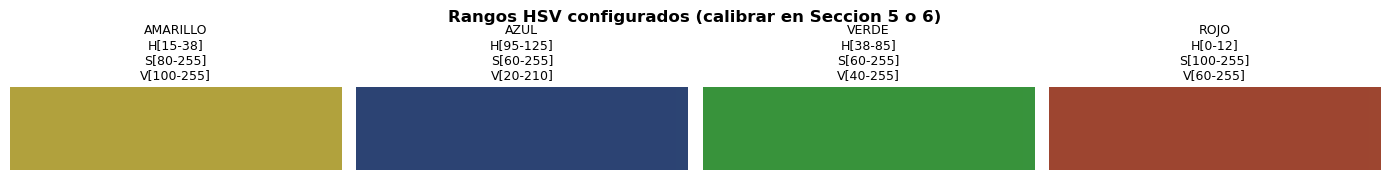

HSV_RANGES definido para 4 colores OK


In [4]:
HSV_RANGES = {
    'amarillo': {
        'lower'      : np.array([ 15,  80, 100]),
        'upper'      : np.array([ 38, 255, 255]),
        'color_bgr'  : (  0, 220, 220),
        'color_label': 'AMARILLO',
    },
    'azul': {
        'lower'      : np.array([ 95,  60,  20]),
        'upper'      : np.array([125, 255, 210]),
        'color_bgr'  : (255,   0,   0),
        'color_label': 'AZUL',
    },
    'verde': {
        'lower'      : np.array([ 38,  60,  40]),
        'upper'      : np.array([ 85, 255, 255]),
        'color_bgr'  : (  0, 200,   0),
        'color_label': 'VERDE',
    },
    'rojo': {
        'lower'      : np.array([  0, 100,  60]),
        'upper'      : np.array([ 12, 255, 255]),
        'lower2'     : np.array([168, 100,  60]),
        'upper2'     : np.array([180, 255, 255]),
        'color_bgr'  : (  0,   0, 220),
        'color_label': 'ROJO',
    },
}

# Visualizar swatches de referencia
fig, axes = plt.subplots(1, 4, figsize=(14, 2))
for ax, (nombre, cfg) in zip(axes, HSV_RANGES.items()):
    mid_h = int((cfg['lower'][0] + cfg['upper'][0]) / 2)
    mid_s = int((cfg['lower'][1] + cfg['upper'][1]) / 2)
    mid_v = int((cfg['lower'][2] + cfg['upper'][2]) / 2)
    swatch = np.zeros((50, 200, 3), dtype=np.uint8)
    swatch[:] = [mid_h, mid_s, mid_v]
    rgb = cv2.cvtColor(swatch, cv2.COLOR_HSV2RGB)
    ax.imshow(rgb)
    ax.set_title(
        f"{nombre.upper()}\nH[{cfg['lower'][0]}-{cfg['upper'][0]}]\n"
        f"S[{cfg['lower'][1]}-{cfg['upper'][1]}]\n"
        f"V[{cfg['lower'][2]}-{cfg['upper'][2]}]", fontsize=9)
    ax.axis('off')
plt.suptitle('Rangos HSV configurados (calibrar en Seccion 5 o 6)', fontweight='bold')
plt.tight_layout()
plt.show()
print('HSV_RANGES definido para 4 colores OK')


## 4. Funciones utilitarias

### 4a. Abrir y liberar cámara

In [5]:
def abrir_camara(camera_index=0):
    # Liberar cualquier proceso que tenga ocupado el dispositivo
    liberar_camara()

    pipeline = (
        f'v4l2src device=/dev/video{camera_index} ! '
        'video/x-raw,format=YUY2,width=640,height=480,framerate=30/1 ! '
        'videoconvert ! video/x-raw,format=BGR ! '
        'appsink drop=true sync=false max-buffers=1'
    )
    cap = cv2.VideoCapture(pipeline, cv2.CAP_GSTREAMER)

    if not cap.isOpened():
        print('GStreamer fallo, probando V4L2...')
        cap = cv2.VideoCapture(f'/dev/video{camera_index}', cv2.CAP_V4L2)
        if not cap.isOpened():
            print('No se pudo abrir la camara.')
            return None

    print(f'Esperando frames de /dev/video{camera_index}...', end='')
    for i in range(40):
        ret, frame = cap.read()
        if ret and frame is not None and frame.size > 0:
            print(f' OK ({i+1} intentos)')
            return cap
        time.sleep(0.1)

    print(' timeout.')
    cap.release()
    return None

def liberar_camara(cap_obj=None):
    """
    Libera el objeto cap dado y mata procesos que bloqueen /dev/video0.
    Si no se pasa cap_obj, solo mata los procesos del sistema.
    """
    if cap_obj is not None:
        cap_obj.release()
    try:
        cv2.destroyAllWindows()
    except Exception:
        pass
    r = subprocess.run(
        'fuser /dev/video0 /dev/video1 2>/dev/null',
        shell=True, capture_output=True, text=True
    )
    pids = r.stdout.strip().split()
    if pids:
        for pid in pids:
            subprocess.run(f'kill -9 {pid}', shell=True)
        print(f'Procesos eliminados: {pids}')
        time.sleep(1)
    else:
        print('Camara libre.')
    gc.collect()


print('abrir_camara() y liberar_camara() definidas OK')


abrir_camara() y liberar_camara() definidas OK


### 4b. P6.3 – Transformación píxel → mm

In [6]:
def pixel_to_mm(cx_px, cy_px):
    """
    P6.3 – Convierte centroide (cx, cy) en pixeles a coordenadas (x, y) en mm
    en el sistema de referencia del robot.

    El eje Y de la imagen va hacia abajo; el del robot hacia arriba -> se invierte.

    Parametros
    ----------
    cx_px, cy_px : float  -- coordenadas del centroide en pixeles

    Retorna
    -------
    (x_mm, y_mm) : tuple[float, float]
    """
    dx_px = cx_px - IMG_WIDTH  / 2.0
    dy_px = cy_px - IMG_HEIGHT / 2.0
    x_mm  = CAM_ORIGIN_X_MM + dx_px * SCALE_X_MM_PX
    y_mm  = CAM_ORIGIN_Y_MM - dy_px * SCALE_Y_MM_PX   # inversion eje Y
    return round(x_mm, 1), round(y_mm, 1)



# Verificacion rapida
casos = [(0, 0), (320, 240), (640, 480), (80, 180), (420, 150)]
print(f"{'Pixeles (cx,cy)':>22} | {'X robot (mm)':>14} | {'Y robot (mm)':>14}")
print('-' * 55)
for cx, cy in casos:
    xm, ym = pixel_to_mm(cx, cy)
    print(f'  ({cx:>3}, {cy:>3})            | {xm:>14.1f} | {ym:>14.1f}')

print('pixel_to_mm() OK')


       Pixeles (cx,cy) |   X robot (mm) |   Y robot (mm)
-------------------------------------------------------
  (  0,   0)            |          -10.0 |          120.0
  (320, 240)            |          150.0 |            0.0
  (640, 480)            |          310.0 |         -120.0
  ( 80, 180)            |           30.0 |           30.0
  (420, 150)            |          200.0 |           45.0
pixel_to_mm() OK


### 4c. P6.2 – Detección principal: contorno y centroide

In [7]:
def detect_object(frame, target_color='amarillo', debug=False):
    """
    P6.2 – Detecta el cubo del color indicado en el frame BGR.
    Calcula el contorno y el centroide (cx, cy) en pixeles con OpenCV.

    Pipeline interno:
        1. Normalizacion de brillo con CLAHE  (robustez a iluminacion variable)
        2. Suavizado GaussianBlur + conversion a HSV
        3. Mascara de color (doble rango para rojo que cruza H=0/180)
        4. Morfologia OPEN+CLOSE  (elimina ruido, rellena huecos)
        5. Contornos externos con cv2.findContours
        6. Seleccion del contorno de mayor area dentro de [MIN_CONTOUR_AREA, MAX_CONTOUR_AREA]
        7. Centroide por momentos de imagen con cv2.moments
        

    Parametros
    ----------
    frame        : imagen BGR (numpy array)
    target_color : 'amarillo' | 'azul' | 'verde' | 'rojo'
    debug        : si True, dibuja bounding box, centroide y etiqueta sobre frame

    Retorna
    -------
    dict {color, cx_px, cy_px, x_mm, y_mm, area}  o  None si no detecta
    """
    if target_color not in HSV_RANGES:
        raise ValueError(f"Color '{target_color}' no definido. "
                         f"Opciones: {list(HSV_RANGES.keys())}")

    cfg = HSV_RANGES[target_color]

    # 1. Normalizar brillo con CLAHE
    lab = cv2.cvtColor(frame, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    frame_eq = cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)

    # 2. Suavizar y convertir a HSV
    blur = cv2.GaussianBlur(frame_eq, (7, 7), 0)
    hsv  = cv2.cvtColor(blur, cv2.COLOR_BGR2HSV)

    # 3. Mascara de color
    mask = cv2.inRange(hsv, cfg['lower'], cfg['upper'])
    if 'lower2' in cfg:
        mask = cv2.bitwise_or(mask, cv2.inRange(hsv, cfg['lower2'], cfg['upper2']))

    # 4. Morfologia: eliminar ruido (OPEN) y rellenar huecos (CLOSE)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask   = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel, iterations=2)
    mask   = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    # 5. Contornos externos
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    valid = [c for c in contours
             if MIN_CONTOUR_AREA < cv2.contourArea(c) < MAX_CONTOUR_AREA]
    if not valid:
        return None

    # 6. Contorno de mayor area
    best = max(valid, key=cv2.contourArea)
    area = cv2.contourArea(best)

    # 7. Centroide con momentos de imagen (P6.2)
    M = cv2.moments(best)
    if M['m00'] == 0:
        return None
    cx = M['m10'] / M['m00']
    cy = M['m01'] / M['m00']
    x_mm, y_mm = pixel_to_mm(cx, cy)

    result = {
        'color' : target_color,
        'cx_px' : round(cx, 1),
        'cy_px' : round(cy, 1),
        'x_mm'  : x_mm,
        'y_mm'  : y_mm,
        'area'  : int(area),
    }

    if debug:
        col    = cfg['color_bgr']
        cx_i, cy_i = int(cx), int(cy)
        bx, by, bw, bh = cv2.boundingRect(best)
        cv2.rectangle(frame, (bx, by), (bx+bw, by+bh), col, 2)
        cv2.circle(frame, (cx_i, cy_i), 7, col, -1)
        cv2.putText(frame,
                    f"{cfg['color_label']}  ({x_mm},{y_mm}) mm",
                    (cx_i + 10, cy_i - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, col, 2)
    return result


def detect_all(frame, debug=False):
    """Detecta los 4 colores definidos en HSV_RANGES en el mismo frame."""
    return {color: detect_object(frame, color, debug=debug)
            for color in HSV_RANGES}


def detectar_color_automatico(frame, debug=False):
    """Prueba los 4 colores y devuelve el resultado con mayor area de contorno."""
    mejor, mayor_area = None, 0
    for color in HSV_RANGES:
        res = detect_object(frame, color)
        if res and res['area'] > mayor_area:
            mayor_area = res['area']
            mejor = res
    if mejor and debug:
        detect_object(frame, mejor['color'], debug=True)
    return mejor


print('detect_object(), detect_all(), detectar_color_automatico() OK')


detect_object(), detect_all(), detectar_color_automatico() OK


### 4d. P6.5 – Detección robusta (falsos positivos, iluminación variable, objeto ausente)

In [8]:
def detect_robust(frame, target_color='amarillo', min_confidence=0.6):
    """
    P6.5 – Version robusta con manejo explicito de:
        - Objeto ausente en la escena
        - Falsos positivos (multiples contornos simultaneos)
        - Iluminacion variable (CLAHE igual que en detect_object)

    La confianza se estima con la circularidad del contorno:
        confidence = (4*pi*area / perimeter^2) / 0.85
    Un cubo perfecto tiene circularidad ~0.785; un blob irregular, mucho menor.

    Parametros
    ----------
    frame          : imagen BGR
    target_color   : color a detectar
    min_confidence : umbral minimo para considerar valida la deteccion (0-1)

    Retorna
    -------
    (result_dict | None, confidence: float, warning: str)
    """
    cfg = HSV_RANGES[target_color]

    lab = cv2.cvtColor(frame, cv2.COLOR_BGR2LAB)
    l, a, b_ch = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    frame_eq = cv2.cvtColor(cv2.merge([l, a, b_ch]), cv2.COLOR_LAB2BGR)

    blur = cv2.GaussianBlur(frame_eq, (7, 7), 0)
    hsv  = cv2.cvtColor(blur, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, cfg['lower'], cfg['upper'])
    if 'lower2' in cfg:
        mask = cv2.bitwise_or(mask, cv2.inRange(hsv, cfg['lower2'], cfg['upper2']))
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask   = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel, iterations=2)
    mask   = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    valid = [c for c in contours
             if MIN_CONTOUR_AREA < cv2.contourArea(c) < MAX_CONTOUR_AREA]

    # Objeto ausente
    if not valid:
        return None, 0.0, 'OBJETO AUSENTE'

    # Falsos positivos: multiples contornos
    warning = ''
    if len(valid) > 1:
        areas = [cv2.contourArea(c) for c in valid]
        ratio = max(areas) / sum(areas)
        if ratio < 0.7:
            warning = (f'ALERTA: {len(valid)} contornos detectados '
                       f'({[int(a) for a in areas]} px2) -- posible falso positivo')

    best = max(valid, key=cv2.contourArea)
    area = cv2.contourArea(best)

    # Estimacion de confianza por circularidad
    perimeter  = cv2.arcLength(best, True)
    confidence = min(1.0, (4 * np.pi * area / (perimeter**2 + 1e-6)) / 0.85)
    if confidence < min_confidence:
        warning += f' | Baja confianza: {confidence:.2f}'

    M = cv2.moments(best)
    if M['m00'] == 0:
        return None, 0.0, 'ERROR: momento nulo'

    cx, cy = M['m10'] / M['m00'], M['m01'] / M['m00']
    x_mm, y_mm = pixel_to_mm(cx, cy)

    result = dict(
        color=target_color,
        cx_px=round(cx, 1), cy_px=round(cy, 1),
        x_mm=x_mm, y_mm=y_mm, area=int(area)
    )
    return result, round(confidence, 3), warning


print('detect_robust() OK')


detect_robust() OK


## 5. Captura de foto desde cámara real

`capturar_foto()` es la función que usa la secuencia principal para tomar la imagen.
Devuelve la ruta de la foto guardada, o `None` si falla.


In [9]:
def capturar_foto(camara_id=0, nombre_archivo='foto_cubo.jpg'):
    """
    Abre la camara, descarta los primeros frames de calentamiento,
    captura uno bueno, lo guarda en disco y lo cierra.

    Retorna la ruta del archivo guardado, o None si falla.
    """
    liberar_camara()
    cap = abrir_camara(camara_id)
    if cap is None:
        print('[FOTO] No se pudo abrir la camara.')
        return None

    # Descartar frames de calentamiento
    for _ in range(10):
        cap.read()

    ret, frame = cap.read()
    cap.release()
    gc.collect()

    if not ret or frame is None:
        print('[FOTO] Error al capturar frame.')
        return None

    cv2.imwrite(nombre_archivo, frame)
    print(f'[FOTO] Guardada: {nombre_archivo}')
    return nombre_archivo


print('capturar_foto() OK')


capturar_foto() OK


## 6. Posiciones del robot

Ajusta estas posiciones según tu calibración real con el robot.


In [10]:
# Posiciones del robot (angulos en grados para send_angles)
POS_HOME         = [0, 0, 0, 0, 0, 0]
POS_DETECCION    = [13.62, -22.58, -66.35,  -7.11,  1.75, -45.35]
POS_BAJAR        = [16.69, -43.85, -61.25,   1.84,  2.46, -44.29]
POS_AZUL         = [117.15, -33.48, -92.63,  38.14,  0.96, -40.86]
POS_AMARILLO     = [ 75.41, -37.88, -69.60,  27.94, -8.96, -53.26]
POS_AMARILLO_BAJ = [ 74.00, -49.92, -69.60,  40.69, -9.05, -53.26]

# Colores con destino definido
DESTINOS = {'AZUL', 'AMARILLO'}

print('Posiciones cargadas:')
for nombre, pos in [
    ('HOME',         POS_HOME),
    ('DETECCION',    POS_DETECCION),
    ('BAJAR',        POS_BAJAR),
    ('AZUL',         POS_AZUL),
    ('AMARILLO',     POS_AMARILLO),
    ('AMARILLO_BAJ', POS_AMARILLO_BAJ),
]:
    print(f'  {nombre:<14}: {pos}')


Posiciones cargadas:
  HOME          : [0, 0, 0, 0, 0, 0]
  DETECCION     : [13.62, -22.58, -66.35, -7.11, 1.75, -45.35]
  BAJAR         : [16.69, -43.85, -61.25, 1.84, 2.46, -44.29]
  AZUL          : [117.15, -33.48, -92.63, 38.14, 0.96, -40.86]
  AMARILLO      : [75.41, -37.88, -69.6, 27.94, -8.96, -53.26]
  AMARILLO_BAJ  : [74.0, -49.92, -69.6, 40.69, -9.05, -53.26]


## 7. Secuencia completa (detección + agarre + colocación)

**Flujo:**
1. HOME → posición de detección
2. Captura foto → detecta color (amarillo o azul)
3. Baja al cubo → cierra gripper
4. HOME → destino según color → suelta gripper
5. Vuelve a HOME

> Ejecuta **Celdas 0–6** antes de correr esta sección.


0. Yendo a posicion HOME...
1. Moviendose a posicion de deteccion...
2. Capturando y detectando color...
Camara libre.
Camara libre.


[ WARN:0@43.515] global cap_gstreamer.cpp:1777 open OpenCV | GStreamer warning: Cannot query video position: status=0, value=-1, duration=-1


Esperando frames de /dev/video0... OK (1 intentos)
[FOTO] Guardada: foto_cubo.jpg


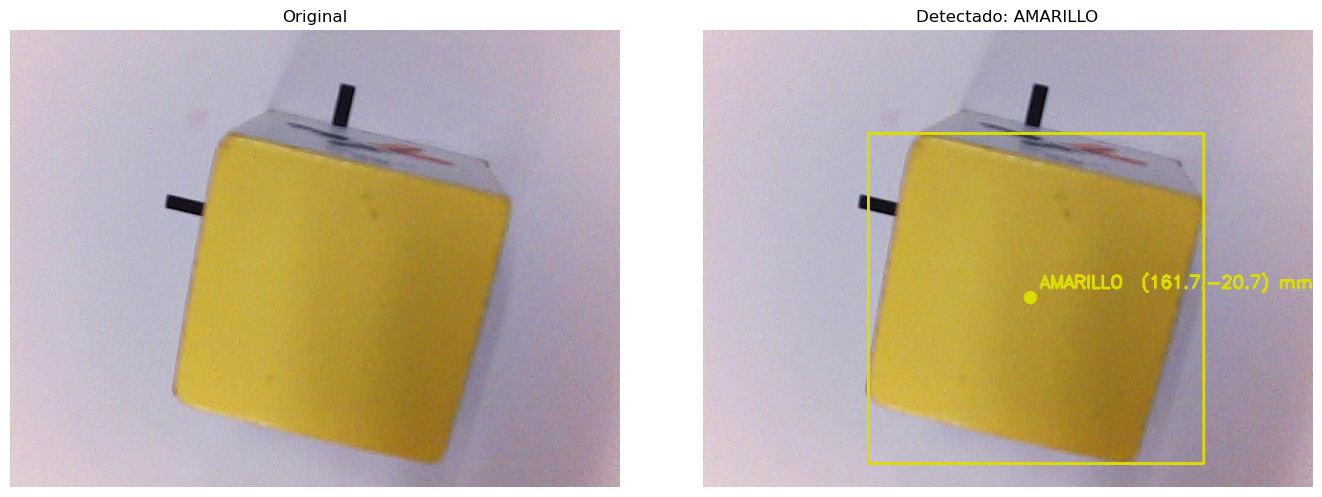


[DETECCION] Color detectado: AMARILLO
  Pixel : (344, 281)
  Robot : (161.7, -20.7) mm
3. Bajando al cubo...
4. Cerrando gripper...
5. Yendo a posicion HOME...
6. Llevando cubo AMARILLO al destino...
7. Bajando para soltar...
8. Soltando gripper...
Volviendo a HOME...

Secuencia completada.


In [13]:
def ejecutar_secuencia(robot, camara_id=0):
    """
    Secuencia completa: detecta color con la camara y lleva el cubo al destino.

    Colores soportados: AMARILLO, AZUL.
    Si detecta otro color o no detecta nada, vuelve a HOME sin mover.
    """
    # 0. HOME
    print('0. Yendo a posicion HOME...')
    robot.send_angles(POS_HOME, 20)
    time.sleep(3)

    # 1. Posicion de deteccion
    print('1. Moviendose a posicion de deteccion...')
    robot.send_angles(POS_DETECCION, 20)
    time.sleep(3)

    # 2. Capturar foto y detectar color
    print('2. Capturando y detectando color...')
    ruta = capturar_foto(camara_id=camara_id)
    if ruta is None:
        print('[ERROR] No se pudo capturar foto. Abortando.')
        robot.send_angles(POS_HOME, 20)
        time.sleep(3)
        return

    frame = cv2.imread(ruta)
    if frame is None:
        print('[ERROR] No se pudo leer la foto guardada. Abortando.')
        robot.send_angles(POS_HOME, 20)
        time.sleep(3)
        return

    frame = cv2.resize(frame, (IMG_WIDTH, IMG_HEIGHT))
    frame_orig = frame.copy()
    frame_anot = frame.copy()

    # Solo buscar amarillo y azul (colores con destino definido)
    resultado = None
    for color_buscar in ['amarillo', 'azul']:
        res = detect_object(frame_anot, color_buscar, debug=True)
        if res:
            resultado = res
            break

    # Mostrar imagen anotada
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].imshow(cv2.cvtColor(frame_orig, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Original')
    axes[1].imshow(cv2.cvtColor(frame_anot, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f'Detectado: {resultado["color"].upper() if resultado else "NINGUNO"}')
    for ax in axes: ax.axis('off')
    plt.tight_layout(); plt.show()

    if resultado is None:
        print('[DETECCION] No se detecto ningun cubo conocido. Volviendo a HOME.')
        robot.send_angles(POS_HOME, 20)
        time.sleep(3)
        return

    color = resultado['color'].upper()
    print(f'\n[DETECCION] Color detectado: {color}')
    print(f'  Pixel : ({resultado["cx_px"]:.0f}, {resultado["cy_px"]:.0f})')
    print(f'  Robot : ({resultado["x_mm"]}, {resultado["y_mm"]}) mm')

    # 3. Bajar al cubo
    print('3. Bajando al cubo...')
    robot.send_angles(POS_BAJAR, 15)
    time.sleep(3)

    # 4. Cerrar gripper
    print('4. Cerrando gripper...')
    robot.set_gripper_state(1, 80)
    time.sleep(2)

    # 5. HOME
    print('5. Yendo a posicion HOME...')
    robot.send_angles(POS_HOME, 20)
    time.sleep(3)

    # 6. Llevar al destino segun color
    if color == 'AZUL':
        print('6. Llevando cubo AZUL al destino...')
        robot.send_angles(POS_AZUL, 20)
        time.sleep(4)
        print('7. Soltando gripper...')
        robot.set_gripper_state(0, 80)
        time.sleep(1)

    elif color == 'AMARILLO':
        print('6. Llevando cubo AMARILLO al destino...')
        robot.send_angles(POS_AMARILLO, 20)
        time.sleep(4)
        print('7. Bajando para soltar...')
        robot.send_angles(POS_AMARILLO_BAJ, 15)
        time.sleep(3)
        print('8. Soltando gripper...')
        robot.set_gripper_state(0, 80)
        time.sleep(1)

    else:
        print(f'[AVISO] Color {color} no tiene destino definido. Soltando en HOME.')
        robot.set_gripper_state(0, 80)
        time.sleep(1)

    # Final: volver a HOME
    print('Volviendo a HOME...')
    robot.send_angles(POS_HOME, 20)
    time.sleep(3)

    print('\nSecuencia completada.')


# LLAMADA (descomentar para ejecutar)
if ROBOT_DISPONIBLE:
    ejecutar_secuencia(mc, camara_id=CAM_INDEX)
else:
    print('Robot no disponible. Conecta el robot y vuelve a ejecutar.')


## 8. P6.1 – Calibración HSV interactiva con sliders

**Flujo:**
1. Ajusta los sliders H/S/V hasta que la máscara aísle bien el cubo.
2. Presiona **Capturar** para ver Original / Máscara / Resultado.
3. Cuando la máscara sea limpia → **Guardar valores** (actualiza `HSV_RANGES` en memoria).
4. Copia los valores impresos a `HSV_RANGES` en la Sección 3 para que persistan.
5. Presiona **Cerrar cámara** al terminar (**importante**).


In [14]:
def calibrar_hsv_jupyter(camera_index=0, color_inicial='amarillo'):
    """Calibrador HSV interactivo con ipywidgets. Sin display GTK."""

    # Mover robot a POS_DETECCION antes de calibrar
    if ROBOT_DISPONIBLE:
        print('Moviendo robot a POS_DETECCION...')
        mc.send_angles(POS_DETECCION, 20)
        time.sleep(3)
        print('Robot en posicion de deteccion. Abriendo camara...')
    else:
        print('Robot no disponible. Calibrando sin mover.')

    cap = abrir_camara(camera_index)
    if cap is None:
        print('Ejecuta liberar_camara() primero (o la Celda 0).')
        return

    cfg0 = HSV_RANGES.get(color_inicial, HSV_RANGES['amarillo'])
    ini_hmin, ini_smin, ini_vmin = cfg0['lower'].tolist()
    ini_hmax, ini_smax, ini_vmax = cfg0['upper'].tolist()

    st = {'description_width': 'initial'}
    lw = widgets.Layout(width='45%')

    h_min = widgets.IntSlider(value=ini_hmin, min=0,   max=179, description='H min', style=st, layout=lw)
    h_max = widgets.IntSlider(value=ini_hmax, min=0,   max=179, description='H max', style=st, layout=lw)
    s_min = widgets.IntSlider(value=ini_smin, min=0,   max=255, description='S min', style=st, layout=lw)
    s_max = widgets.IntSlider(value=ini_smax, min=0,   max=255, description='S max', style=st, layout=lw)
    v_min = widgets.IntSlider(value=ini_vmin, min=0,   max=255, description='V min', style=st, layout=lw)
    v_max = widgets.IntSlider(value=ini_vmax, min=0,   max=255, description='V max', style=st, layout=lw)

    sel_color = widgets.Dropdown(
        options=list(HSV_RANGES.keys()), value=color_inicial,
        description='Color:', style=st, layout=widgets.Layout(width='200px'))

    btn_load = widgets.Button(description='Cargar color',    button_style='warning')
    btn_cap  = widgets.Button(description='Capturar',        button_style='primary')
    btn_save = widgets.Button(description='Guardar valores', button_style='success')
    btn_quit = widgets.Button(description='Cerrar camara',   button_style='danger')
    out      = widgets.Output()

    display(widgets.VBox([
        widgets.HBox([sel_color, btn_load]),
        widgets.HTML('<b>Rangos HSV</b>'),
        widgets.HBox([h_min, h_max]),
        widgets.HBox([s_min, s_max]),
        widgets.HBox([v_min, v_max]),
        widgets.HBox([btn_cap, btn_save, btn_quit]),
        out
    ]))

    def _get_frame():
        for _ in range(30):
            ret, frame = cap.read()
            if ret and frame is not None and frame.size > 0:
                return True, frame
            time.sleep(0.05)
        return False, None

    def _mostrar(frame, lower, upper):
        hsv_f  = cv2.cvtColor(cv2.GaussianBlur(frame, (7, 7), 0), cv2.COLOR_BGR2HSV)
        mask   = cv2.inRange(hsv_f, lower, upper)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
        mask   = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel, iterations=2)
        mask   = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

        frame_vis = frame.copy()
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        valid = [c for c in contours
                 if MIN_CONTOUR_AREA < cv2.contourArea(c) < MAX_CONTOUR_AREA]

        for c in valid:
            M = cv2.moments(c)
            if M['m00'] > 0:
                cx_c = int(M['m10'] / M['m00'])
                cy_c = int(M['m01'] / M['m00'])
                bx, by, bw, bh = cv2.boundingRect(c)
                xmm, ymm = pixel_to_mm(cx_c, cy_c)
                cv2.rectangle(frame_vis, (bx, by), (bx+bw, by+bh), (0, 255, 0), 2)
                cv2.circle(frame_vis, (cx_c, cy_c), 6, (0, 255, 0), -1)
                cv2.putText(frame_vis, f'robot({xmm},{ymm})mm',
                            (bx, max(by - 8, 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

        overlay = frame_vis.copy()
        cv2.rectangle(overlay, (0, 0), (frame_vis.shape[1], 38), (0, 0, 0), -1)
        cv2.addWeighted(overlay, 0.55, frame_vis, 0.45, 0, frame_vis)
        estado_txt = (f'DETECTADO: {sel_color.value.upper()} | {len(valid)} contorno(s)'
                      if valid else 'NO DETECTADO -- ajusta HSV')
        color_txt = (0, 255, 0) if valid else (0, 0, 255)
        cv2.putText(frame_vis, estado_txt, (10, 26),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color_txt, 2)

        result_img = cv2.bitwise_and(frame, frame, mask=mask)
        fig, axes  = plt.subplots(1, 3, figsize=(15, 4))
        for ax, img, t in zip(
            axes,
            [cv2.cvtColor(frame_vis, cv2.COLOR_BGR2RGB), mask,
             cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)],
            [f'Original ({len(valid)} detectados)', 'Mascara', 'Resultado filtrado']
        ):
            ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
            ax.set_title(t); ax.axis('off')
        fig.suptitle(
            f'H[{lower[0]}-{upper[0]}]  S[{lower[1]}-{upper[1]}]  V[{lower[2]}-{upper[2]}]',
            fontsize=11)
        with out:
            clear_output(wait=True)
            plt.tight_layout(); plt.show()

    def cargar_color(_):
        cfg = HSV_RANGES[sel_color.value]
        h_min.value, s_min.value, v_min.value = cfg['lower'].tolist()
        h_max.value, s_max.value, v_max.value = cfg['upper'].tolist()
        with out:
            clear_output(wait=True)
            print(f"Valores de '{sel_color.value}' cargados.")

    def capturar(_):
        with out:
            clear_output(wait=True); print('Capturando...')
        ok, frame = _get_frame()
        if not ok:
            with out:
                clear_output(wait=True)
                print('No se pudo leer frame. Presiona [Cerrar camara] y vuelve a ejecutar.')
            return
        lower = np.array([h_min.value, s_min.value, v_min.value])
        upper = np.array([h_max.value, s_max.value, v_max.value])
        _mostrar(frame, lower, upper)

    def guardar(_):
        color = sel_color.value
        with out:
            print(f"\n=== Pegar en HSV_RANGES['{color}'] (Seccion 3) ===")
            print(f"  'lower': np.array([{h_min.value}, {s_min.value}, {v_min.value}]),")
            print(f"  'upper': np.array([{h_max.value}, {s_max.value}, {v_max.value}]),")
            HSV_RANGES[color]['lower'] = np.array([h_min.value, s_min.value, v_min.value])
            HSV_RANGES[color]['upper'] = np.array([h_max.value, s_max.value, v_max.value])
            print('HSV_RANGES actualizado en memoria OK')

    def cerrar(_):
        cap.release(); gc.collect()
        with out:
            clear_output(wait=True); print('Camara cerrada correctamente.')

    btn_load.on_click(cargar_color)
    btn_cap.on_click(capturar)
    btn_save.on_click(guardar)
    btn_quit.on_click(cerrar)


calibrar_hsv_jupyter(camera_index=CAM_INDEX, color_inicial='amarillo')

Moviendo robot a POS_DETECCION...
Robot en posicion de deteccion. Abriendo camara...
Camara libre.
Esperando frames de /dev/video0... OK (1 intentos)


[ WARN:0@70.972] global cap_gstreamer.cpp:1777 open OpenCV | GStreamer warning: Cannot query video position: status=0, value=-1, duration=-1


In [11]:
def calibrar_hsv_jupyter(camera_index=0, color_inicial='amarillo'):
    """Calibrador HSV interactivo con ipywidgets. Sin display GTK."""

    # Mover robot a POS_DETECCION antes de calibrar
    if ROBOT_DISPONIBLE:
        print('Moviendo robot a POS_DETECCION...')
        mc.send_angles(POS_DETECCION, 20)
        time.sleep(3)
        print('Robot en posicion de deteccion. Abriendo camara...')
    else:
        print('Robot no disponible. Calibrando sin mover.')

    # Forzar liberacion completa antes de abrir
    try:
        cap.release()
    except Exception:
        pass
    liberar_camara()
    time.sleep(1.5)  # esperar que el SO libere /dev/video0

    cap = abrir_camara(camera_index)
    if cap is None:
        print('No se pudo abrir la camara.')
        return

    cfg0 = HSV_RANGES.get(color_inicial, HSV_RANGES['amarillo'])
    ini_hmin, ini_smin, ini_vmin = cfg0['lower'].tolist()
    ini_hmax, ini_smax, ini_vmax = cfg0['upper'].tolist()

    st = {'description_width': 'initial'}
    lw = widgets.Layout(width='45%')

    h_min = widgets.IntSlider(value=ini_hmin, min=0,   max=179, description='H min', style=st, layout=lw)
    h_max = widgets.IntSlider(value=ini_hmax, min=0,   max=179, description='H max', style=st, layout=lw)
    s_min = widgets.IntSlider(value=ini_smin, min=0,   max=255, description='S min', style=st, layout=lw)
    s_max = widgets.IntSlider(value=ini_smax, min=0,   max=255, description='S max', style=st, layout=lw)
    v_min = widgets.IntSlider(value=ini_vmin, min=0,   max=255, description='V min', style=st, layout=lw)
    v_max = widgets.IntSlider(value=ini_vmax, min=0,   max=255, description='V max', style=st, layout=lw)

    sel_color = widgets.Dropdown(
        options=list(HSV_RANGES.keys()), value=color_inicial,
        description='Color:', style=st, layout=widgets.Layout(width='200px'))

    btn_load = widgets.Button(description='Cargar color',    button_style='warning')
    btn_cap  = widgets.Button(description='Capturar',        button_style='primary')
    btn_save = widgets.Button(description='Guardar valores', button_style='success')
    btn_quit = widgets.Button(description='Cerrar camara',   button_style='danger')
    out      = widgets.Output()

    display(widgets.VBox([
        widgets.HBox([sel_color, btn_load]),
        widgets.HTML('<b>Rangos HSV</b>'),
        widgets.HBox([h_min, h_max]),
        widgets.HBox([s_min, s_max]),
        widgets.HBox([v_min, v_max]),
        widgets.HBox([btn_cap, btn_save, btn_quit]),
        out
    ]))

    def _get_frame():
        for _ in range(30):
            ret, frame = cap.read()
            if ret and frame is not None and frame.size > 0:
                return True, frame
            time.sleep(0.05)
        return False, None

    def _mostrar(frame, lower, upper):
        hsv_f  = cv2.cvtColor(cv2.GaussianBlur(frame, (7, 7), 0), cv2.COLOR_BGR2HSV)
        mask   = cv2.inRange(hsv_f, lower, upper)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
        mask   = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel, iterations=2)
        mask   = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

        frame_vis = frame.copy()
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        valid = [c for c in contours
                 if MIN_CONTOUR_AREA < cv2.contourArea(c) < MAX_CONTOUR_AREA]

        for c in valid:
            M = cv2.moments(c)
            if M['m00'] > 0:
                cx_c = int(M['m10'] / M['m00'])
                cy_c = int(M['m01'] / M['m00'])
                bx, by, bw, bh = cv2.boundingRect(c)
                xmm, ymm = pixel_to_mm(cx_c, cy_c)
                cv2.rectangle(frame_vis, (bx, by), (bx+bw, by+bh), (0, 255, 0), 2)
                cv2.circle(frame_vis, (cx_c, cy_c), 6, (0, 255, 0), -1)
                cv2.putText(frame_vis, f'robot({xmm},{ymm})mm',
                            (bx, max(by - 8, 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

        overlay = frame_vis.copy()
        cv2.rectangle(overlay, (0, 0), (frame_vis.shape[1], 38), (0, 0, 0), -1)
        cv2.addWeighted(overlay, 0.55, frame_vis, 0.45, 0, frame_vis)
        estado_txt = (f'DETECTADO: {sel_color.value.upper()} | {len(valid)} contorno(s)'
                      if valid else 'NO DETECTADO -- ajusta HSV')
        color_txt = (0, 255, 0) if valid else (0, 0, 255)
        cv2.putText(frame_vis, estado_txt, (10, 26),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color_txt, 2)

        result_img = cv2.bitwise_and(frame, frame, mask=mask)
        fig, axes  = plt.subplots(1, 3, figsize=(15, 4))
        for ax, img, t in zip(
            axes,
            [cv2.cvtColor(frame_vis, cv2.COLOR_BGR2RGB), mask,
             cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)],
            [f'Original ({len(valid)} detectados)', 'Mascara', 'Resultado filtrado']
        ):
            ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
            ax.set_title(t); ax.axis('off')
        fig.suptitle(
            f'H[{lower[0]}-{upper[0]}]  S[{lower[1]}-{upper[1]}]  V[{lower[2]}-{upper[2]}]',
            fontsize=11)
        with out:
            clear_output(wait=True)
            plt.tight_layout(); plt.show()

    def cargar_color(_):
        cfg = HSV_RANGES[sel_color.value]
        h_min.value, s_min.value, v_min.value = cfg['lower'].tolist()
        h_max.value, s_max.value, v_max.value = cfg['upper'].tolist()
        with out:
            clear_output(wait=True)
            print(f"Valores de '{sel_color.value}' cargados.")

    def capturar(_):
        with out:
            clear_output(wait=True); print('Capturando...')
        ok, frame = _get_frame()
        if not ok:
            with out:
                clear_output(wait=True)
                print('No se pudo leer frame. Presiona [Cerrar camara] y vuelve a ejecutar.')
            return
        lower = np.array([h_min.value, s_min.value, v_min.value])
        upper = np.array([h_max.value, s_max.value, v_max.value])
        _mostrar(frame, lower, upper)

    def guardar(_):
        color = sel_color.value
        with out:
            print(f"\n=== Pegar en HSV_RANGES['{color}'] (Seccion 3) ===")
            print(f"  'lower': np.array([{h_min.value}, {s_min.value}, {v_min.value}]),")
            print(f"  'upper': np.array([{h_max.value}, {s_max.value}, {v_max.value}]),")
            HSV_RANGES[color]['lower'] = np.array([h_min.value, s_min.value, v_min.value])
            HSV_RANGES[color]['upper'] = np.array([h_max.value, s_max.value, v_max.value])
            print('HSV_RANGES actualizado en memoria OK')

    def cerrar(_):
        cap.release()
        liberar_camara()  # también mata procesos al cerrar
        gc.collect()
        with out:
            clear_output(wait=True); print('Camara cerrada correctamente.')

    btn_load.on_click(cargar_color)
    btn_cap.on_click(capturar)
    btn_save.on_click(guardar)
    btn_quit.on_click(cerrar)


calibrar_hsv_jupyter(camera_index=CAM_INDEX, color_inicial='amarillo')

Moviendo robot a POS_DETECCION...
Robot en posicion de deteccion. Abriendo camara...
Camara libre.
Camara libre.
Esperando frames de /dev/video0... OK (1 intentos)


[ WARN:0@43.734] global cap_gstreamer.cpp:1777 open OpenCV | GStreamer warning: Cannot query video position: status=0, value=-1, duration=-1


Moviendo a WATCH: [13.62, -22.58, -66.35, -7.11, 1.75, -45.35]
Robot en posicion. Capturando...
Camara libre.
Camara libre.
Esperando frames de /dev/video0... OK (1 intentos)


[ WARN:0@209.849] global cap_gstreamer.cpp:1777 open OpenCV | GStreamer warning: Cannot query video position: status=0, value=-1, duration=-1


Camara libre.
=== HSV en la region muestreada ===
  H: min=0  max=179  media=95.2
  S: min=0  max=255  media=98.1
  V: min=0  max=224  media=174.3
  -> lower = np.array([0, 0, 0])
  -> upper = np.array([179, 255, 255])
HSV_RANGES[amarillo] actualizado en memoria OK
-> Copia estos valores a la Seccion 3 para que persistan.

No se detecto contorno valido -- ajusta la ROI sobre el cubo.


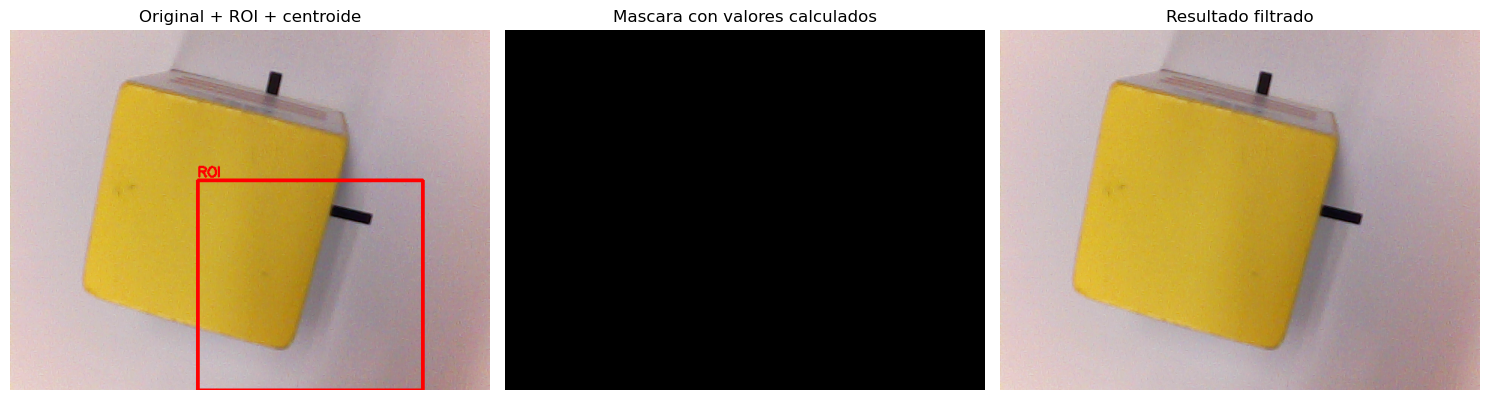

In [14]:
def samplear_hsv(x1=120, y1=130, x2=320, y2=350, camera_index=CAM_INDEX, pose=None):
    """
    Captura un frame, calcula los rangos HSV de la region [y1:y2, x1:x2]
    y actualiza HSV_RANGES['amarillo']. Muestra el centroide detectado en px y mm.

    Parametros
    ----------
    x1,y1,x2,y2   : recorte ROI sobre el cubo (en pixeles)
    camera_index   : indice de camara
    pose           : 'watch' | 'pick' | 'place' | None  -> mueve el robot antes de capturar
    """
    poses_disponibles = {
        'watch' : POS_DETECCION,
        'pick'  : PICK_UPPER,
        'place' : PLACE_UPPER,
    }

    if pose is not None:
        if pose not in poses_disponibles:
            print(f'Pose "{pose}" no existe. Opciones: {list(poses_disponibles.keys())}')
            return
        if ROBOT_DISPONIBLE:
            print(f'Moviendo a {pose.upper()}: {poses_disponibles[pose]}')
            mc.send_angles(poses_disponibles[pose], WATCH_SPEED)
            time.sleep(3)
            print('Robot en posicion. Capturando...')
        else:
            print('Robot no disponible -- capturando sin mover.')

    # Forzar liberacion completa antes de abrir
    try:
        cap.release()
    except Exception:
        pass
    liberar_camara()
    time.sleep(1.5)  # esperar que el SO libere /dev/video0

    cap = abrir_camara(camera_index)
    if cap is None:
        print('No se pudo abrir la camara. Ejecuta la Celda 0 primero.')
        return
    for _ in range(5):
        cap.read()
    ret, frame = cap.read()
    cap.release()
    liberar_camara()  # limpiar al cerrar
    gc.collect()

    if not ret:
        print('Error al capturar frame.')
        return

    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    roi = hsv[y1:y2, x1:x2]

    if roi.size == 0:
        print('ROI vacia -- revisa que x1<x2 y y1<y2 y dentro de la imagen.')
        return

    h_lo = max(0,   int(roi[:, :, 0].min()) - 8)
    h_hi = min(179, int(roi[:, :, 0].max()) + 8)
    s_lo = max(0,   int(roi[:, :, 1].min()) - 20)
    v_lo = max(0,   int(roi[:, :, 2].min()) - 20)

    print('=== HSV en la region muestreada ===')
    print(f'  H: min={roi[:,:,0].min()}  max={roi[:,:,0].max()}  media={roi[:,:,0].mean():.1f}')
    print(f'  S: min={roi[:,:,1].min()}  max={roi[:,:,1].max()}  media={roi[:,:,1].mean():.1f}')
    print(f'  V: min={roi[:,:,2].min()}  max={roi[:,:,2].max()}  media={roi[:,:,2].mean():.1f}')
    print(f'  -> lower = np.array([{h_lo}, {s_lo}, {v_lo}])')
    print(f'  -> upper = np.array([{h_hi}, 255, 255])')

    HSV_RANGES['amarillo']['lower'] = np.array([h_lo, s_lo, v_lo])
    HSV_RANGES['amarillo']['upper'] = np.array([h_hi, 255, 255])
    print('HSV_RANGES[amarillo] actualizado en memoria OK')
    print('-> Copia estos valores a la Seccion 3 para que persistan.')

    # Detectar contorno y centroide con los rangos calculados
    mask = cv2.inRange(hsv, np.array([h_lo, s_lo, v_lo]), np.array([h_hi, 255, 255]))
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    valid = [c for c in contours if MIN_CONTOUR_AREA < cv2.contourArea(c) < MAX_CONTOUR_AREA]

    cx = cy = None
    if valid:
        best = max(valid, key=cv2.contourArea)
        M = cv2.moments(best)
        if M['m00'] > 0:
            cx = int(M['m10'] / M['m00'])
            cy = int(M['m01'] / M['m00'])
            x_mm, y_mm = pixel_to_mm(cx, cy)
            print(f'\n=== Centroide detectado ===')
            print(f'  Pixel  : cx={cx}, cy={cy}')
            print(f'  Robot  : x={x_mm} mm, y={y_mm} mm')
            print(f'  Area   : {int(cv2.contourArea(best))} px2')
    else:
        print('\nNo se detecto contorno valido -- ajusta la ROI sobre el cubo.')

    # Visualizacion
    frame_roi = frame.copy()
    cv2.rectangle(frame_roi, (x1, y1), (x2, y2), (0, 0, 255), 3)
    cv2.putText(frame_roi, 'ROI', (x1, max(y1 - 5, 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)
    if cx is not None:
        cv2.circle(frame_roi, (cx, cy), 8, (0, 255, 0), -1)
        cv2.putText(frame_roi, f'cx={cx} cy={cy}', (cx + 10, cy - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].imshow(cv2.cvtColor(frame_roi, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Original + ROI + centroide'); axes[0].axis('off')
    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title('Mascara con valores calculados'); axes[1].axis('off')
    axes[2].imshow(cv2.cvtColor(cv2.bitwise_and(frame, frame, mask=mask), cv2.COLOR_BGR2RGB))
    axes[2].set_title('Resultado filtrado'); axes[2].axis('off')
    plt.tight_layout()
    plt.show()


# Descomenta la opcion que necesites:
samplear_hsv(x1=250, y1=200, x2=550, y2=480, pose='watch')
# samplear_hsv(x1=120, y1=130, x2=320, y2=350, pose='pick')
# samplear_hsv(x1=120, y1=130, x2=320, y2=350)   # sin mover robot

## 12. P6.4 – Validación en ≥ 3 posiciones

**Procedimiento para cada posición:**
1. Coloca el cubo en la posición deseada.
2. Lee `mc.get_coords()` → anota `X_real`, `Y_real`.
3. Edita `posicion_real_mm` con esos valores.
4. Ejecuta la celda → detecta con la cámara y compara.

La tabla se acumula automáticamente. Repite 3 veces cambiando la posición del cubo.

> **Criterio de éxito:** error < 15 mm en X e Y.


Camara libre.
Esperando frames de /dev/video0... OK (1 intentos)


[ WARN:0@252.736] global cap_gstreamer.cpp:1777 open OpenCV | GStreamer warning: Cannot query video position: status=0, value=-1, duration=-1


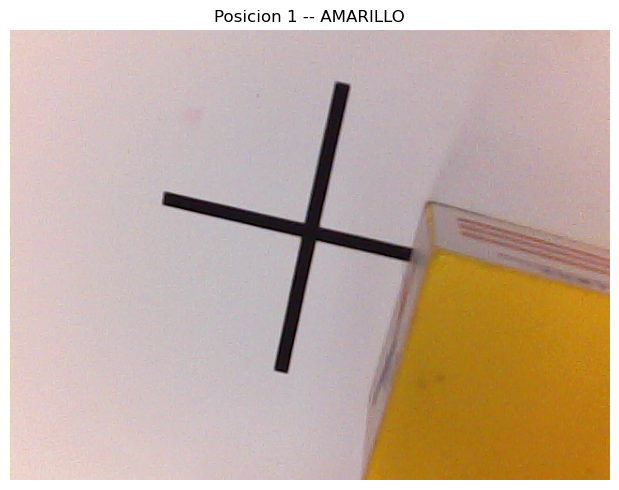

Sin deteccion. Revisa HSV o iluminacion.


In [16]:
# Acumula entre ejecuciones -- NO reiniciar entre posiciones
try:
    tabla_validacion
except NameError:
    tabla_validacion = []

# EDITAR ANTES DE CADA MEDICION
posicion_real_mm = (150.0, 0.0)   # (x_real, y_real) en mm -- leer con mc.get_coords()
color_a_detectar = 'amarillo'     # color del cubo en esta posicion
UMBRAL_ERROR_MM  = 15.0           # tolerancia maxima en mm

# Captura y deteccion
cap = abrir_camara(CAM_INDEX)
if cap is not None:
    for _ in range(5):
        cap.read()
    ret, frame = cap.read()
    cap.release()
    gc.collect()

    if ret:
        frame_vis = frame.copy()
        det = detect_object(frame_vis, color_a_detectar, debug=True)

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.imshow(cv2.cvtColor(frame_vis, cv2.COLOR_BGR2RGB))
        ax.set_title(f'Posicion {len(tabla_validacion)+1} -- {color_a_detectar.upper()}')
        ax.axis('off')
        plt.tight_layout(); plt.show()

        ex, ey = posicion_real_mm
        if det:
            err_x  = abs(det['x_mm'] - ex)
            err_y  = abs(det['y_mm'] - ey)
            estado = 'OK' if max(err_x, err_y) < UMBRAL_ERROR_MM else 'FALLO'
            tabla_validacion.append((
                len(tabla_validacion) + 1, color_a_detectar,
                ex, ey, det['x_mm'], det['y_mm'], err_x, err_y, estado
            ))
            print(f'Real : x={ex}, y={ey}')
            print(f'Det  : x={det["x_mm"]}, y={det["y_mm"]}')
            print(f'Error: DX={err_x:.1f} mm  DY={err_y:.1f} mm  [{estado}]')
        else:
            print('Sin deteccion. Revisa HSV o iluminacion.')
    else:
        print('Error al capturar frame.')

# Tabla acumulada
if tabla_validacion:
    print(f'\n{"Pos":>3} {"Color":>10} {"X_real":>8} {"Y_real":>8} '
          f'{"X_det":>8} {"Y_det":>8} {"DX":>7} {"DY":>7} {"Estado":>8}')
    print('-' * 78)
    for row in tabla_validacion:
        i, col, xr, yr, xd, yd, ex, ey, est = row
        print(f'{i:>3} {col:>10} {xr:>8.1f} {yr:>8.1f} '
              f'{xd:>8.1f} {yd:>8.1f} {ex:>7.1f} {ey:>7.1f} {est:>8}')
    errores_x = [r[6] for r in tabla_validacion]
    errores_y = [r[7] for r in tabla_validacion]
    ok_count  = sum(1 for r in tabla_validacion if r[8] == 'OK')
    print(f'\nError medio : DX={sum(errores_x)/len(errores_x):.1f} mm  DY={sum(errores_y)/len(errores_y):.1f} mm')
    print(f'Posiciones OK: {ok_count}/{len(tabla_validacion)}  (objetivo: {len(tabla_validacion)}/{len(tabla_validacion)})')


## 13. `get_object_position()` — interfaz para `main.py`

Esta función es el punto de publicación de la detección hacia el sistema de integración.

```python
# En main.py:
from P6_deteccion_objetos import get_object_position

pos = get_object_position()      # retorna (x_mm, y_mm) o None
if pos:
    x_mm, y_mm = pos
```


In [11]:
def calibrar_hsv_jupyter(camera_index=0, color_inicial='amarillo'):
    """Calibrador HSV interactivo con ipywidgets. Sin display GTK."""

    if ROBOT_DISPONIBLE:
        print('Moviendo robot a POS_DETECCION...')
        mc.send_angles(POS_DETECCION, 20)
        time.sleep(3)
        print('Robot en posicion de deteccion. Abriendo camara...')
    else:
        print('Robot no disponible. Calibrando sin mover.')

    try:
        cap.release()
    except Exception:
        pass
    liberar_camara()
    time.sleep(1.5)

    cap = abrir_camara(camera_index)
    if cap is None:
        print('No se pudo abrir la camara.')
        return

    # Descartar frames de calentamiento
    for _ in range(10):
        cap.read()

    cfg0 = HSV_RANGES.get(color_inicial, HSV_RANGES['amarillo'])
    ini_hmin, ini_smin, ini_vmin = cfg0['lower'].tolist()
    ini_hmax, ini_smax, ini_vmax = cfg0['upper'].tolist()

    st = {'description_width': 'initial'}
    lw = widgets.Layout(width='45%')

    # Valores iniciales razonables para amarillo
    h_min = widgets.IntSlider(value=ini_hmin, min=0,   max=179, description='H min', style=st, layout=lw)
    h_max = widgets.IntSlider(value=ini_hmax, min=0,   max=179, description='H max', style=st, layout=lw)
    s_min = widgets.IntSlider(value=ini_smin, min=0,   max=255, description='S min', style=st, layout=lw)
    s_max = widgets.IntSlider(value=255,       min=0,   max=255, description='S max', style=st, layout=lw)
    v_min = widgets.IntSlider(value=ini_vmin, min=0,   max=255, description='V min', style=st, layout=lw)
    v_max = widgets.IntSlider(value=255,       min=0,   max=255, description='V max', style=st, layout=lw)

    sel_color = widgets.Dropdown(
        options=list(HSV_RANGES.keys()), value=color_inicial,
        description='Color:', style=st, layout=widgets.Layout(width='200px'))

    btn_load = widgets.Button(description='Cargar color',    button_style='warning')
    btn_cap  = widgets.Button(description='Capturar',        button_style='primary')
    btn_save = widgets.Button(description='Guardar valores', button_style='success')
    btn_quit = widgets.Button(description='Cerrar camara',   button_style='danger')

    # Botones de presets para arrancar rapido
    btn_preset_am  = widgets.Button(description='Preset Amarillo', button_style='info')
    btn_preset_az  = widgets.Button(description='Preset Azul',     button_style='info')

    out = widgets.Output()

    display(widgets.VBox([
        widgets.HBox([sel_color, btn_load]),
        widgets.HTML('<b>Rangos HSV</b>'),
        widgets.HBox([h_min, h_max]),
        widgets.HBox([s_min, s_max]),
        widgets.HBox([v_min, v_max]),
        widgets.HTML('<b>Presets de inicio rapido:</b>'),
        widgets.HBox([btn_preset_am, btn_preset_az]),
        widgets.HBox([btn_cap, btn_save, btn_quit]),
        out
    ]))

    def _get_frame():
        for _ in range(5):
            cap.read()
        for _ in range(30):
            ret, frame = cap.read()
            if ret and frame is not None and frame.size > 0:
                return True, frame
            time.sleep(0.05)
        return False, None

    def _mostrar(frame, lower, upper):
        # Pipeline IDENTICO a detect_object con CLAHE
        lab = cv2.cvtColor(frame, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        l = clahe.apply(l)
        frame_eq = cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)

        blur  = cv2.GaussianBlur(frame_eq, (7, 7), 0)
        hsv_f = cv2.cvtColor(blur, cv2.COLOR_BGR2HSV)

        mask   = cv2.inRange(hsv_f, lower, upper)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
        mask   = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel, iterations=2)
        mask   = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

        frame_vis = frame.copy()
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        valid = [c for c in contours
                 if MIN_CONTOUR_AREA < cv2.contourArea(c) < MAX_CONTOUR_AREA]

        for c in valid:
            M = cv2.moments(c)
            if M['m00'] > 0:
                cx_c = int(M['m10'] / M['m00'])
                cy_c = int(M['m01'] / M['m00'])
                bx, by, bw, bh = cv2.boundingRect(c)
                xmm, ymm = pixel_to_mm(cx_c, cy_c)
                cv2.rectangle(frame_vis, (bx, by), (bx+bw, by+bh), (0, 255, 0), 2)
                cv2.circle(frame_vis, (cx_c, cy_c), 6, (0, 255, 0), -1)
                cv2.putText(frame_vis, f'robot({xmm},{ymm})mm',
                            (bx, max(by - 8, 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

        overlay = frame_vis.copy()
        cv2.rectangle(overlay, (0, 0), (frame_vis.shape[1], 38), (0, 0, 0), -1)
        cv2.addWeighted(overlay, 0.55, frame_vis, 0.45, 0, frame_vis)
        estado_txt = (f'DETECTADO: {sel_color.value.upper()} | {len(valid)} contorno(s)'
                      if valid else 'NO DETECTADO -- ajusta HSV')
        color_txt = (0, 255, 0) if valid else (0, 0, 255)
        cv2.putText(frame_vis, estado_txt, (10, 26),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color_txt, 2)

        result_img = cv2.bitwise_and(frame, frame, mask=mask)
        fig, axes  = plt.subplots(1, 3, figsize=(15, 4))
        for ax, img, t in zip(
            axes,
            [cv2.cvtColor(frame_vis, cv2.COLOR_BGR2RGB), mask,
             cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)],
            [f'Original ({len(valid)} detectados)', 'Mascara', 'Resultado filtrado']
        ):
            ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
            ax.set_title(t); ax.axis('off')
        fig.suptitle(
            f'H[{lower[0]}-{upper[0]}]  S[{lower[1]}-{upper[1]}]  V[{lower[2]}-{upper[2]}]',
            fontsize=11)
        with out:
            clear_output(wait=True)
            plt.tight_layout(); plt.show()

    def preset_amarillo(_):
        h_min.value, h_max.value = 15, 38
        s_min.value, s_max.value = 80, 255
        v_min.value, v_max.value = 100, 255
        with out:
            clear_output(wait=True)
            print('Preset amarillo cargado. Presiona Capturar.')

    def preset_azul(_):
        h_min.value, h_max.value = 95, 125
        s_min.value, s_max.value = 60, 255
        v_min.value, v_max.value = 20, 210
        with out:
            clear_output(wait=True)
            print('Preset azul cargado. Presiona Capturar.')

    def cargar_color(_):
        cfg = HSV_RANGES[sel_color.value]
        h_min.value, s_min.value, v_min.value = cfg['lower'].tolist()
        h_max.value, s_max.value, v_max.value = cfg['upper'].tolist()
        with out:
            clear_output(wait=True)
            print(f"Valores de '{sel_color.value}' cargados.")

    def capturar(_):
        with out:
            clear_output(wait=True); print('Capturando...')
        ok, frame = _get_frame()
        if not ok:
            with out:
                clear_output(wait=True)
                print('No se pudo leer frame. Presiona [Cerrar camara] y vuelve a ejecutar.')
            return
        lower = np.array([h_min.value, s_min.value, v_min.value])
        upper = np.array([h_max.value, s_max.value, v_max.value])
        _mostrar(frame, lower, upper)

    def guardar(_):
        color = sel_color.value
        with out:
            print(f"\n=== Pegar en HSV_RANGES['{color}'] (Seccion 3) ===")
            print(f"  'lower': np.array([{h_min.value}, {s_min.value}, {v_min.value}]),")
            print(f"  'upper': np.array([{h_max.value}, {s_max.value}, {v_max.value}]),")
            HSV_RANGES[color]['lower'] = np.array([h_min.value, s_min.value, v_min.value])
            HSV_RANGES[color]['upper'] = np.array([h_max.value, s_max.value, v_max.value])
            print('HSV_RANGES actualizado en memoria OK')

    def cerrar(_):
        cap.release()
        liberar_camara()
        gc.collect()
        with out:
            clear_output(wait=True); print('Camara cerrada correctamente.')

    btn_load.on_click(cargar_color)
    btn_cap.on_click(capturar)
    btn_save.on_click(guardar)
    btn_quit.on_click(cerrar)
    btn_preset_am.on_click(preset_amarillo)
    btn_preset_az.on_click(preset_azul)


calibrar_hsv_jupyter(camera_index=CAM_INDEX, color_inicial='amarillo')

Moviendo robot a POS_DETECCION...
Robot en posicion de deteccion. Abriendo camara...
Camara libre.
Camara libre.


[ WARN:0@61.722] global cap_gstreamer.cpp:1777 open OpenCV | GStreamer warning: Cannot query video position: status=0, value=-1, duration=-1


Esperando frames de /dev/video0... OK (1 intentos)


In [11]:
def get_object_position(target_color='amarillo', cam_index=CAM_INDEX, retries=5):
    """
    Interfaz publica para main.py.
    Abre la camara, intenta detectar el cubo hasta `retries` veces
    usando detect_robust (robusto ante ausencia, falsos positivos e iluminacion).
    Cierra la camara y retorna el resultado.
    Parametros
    ----------
    target_color : color a detectar
    cam_index    : indice de camara
    retries      : numero maximo de intentos
    Retorna
    -------
    (x_mm, y_mm) : tuple[float, float]  si detecta
    None          : si no detecta tras todos los intentos
    """
    # Mover robot a posicion de deteccion
    if ROBOT_DISPONIBLE:
        print('[VISION] Moviendo a POS_DETECCION...')
        mc.send_angles(POS_DETECCION, 20)
        time.sleep(3)

    # Liberar camara antes de abrir
    try:
        cap.release()
    except Exception:
        pass
    liberar_camara()
    time.sleep(1.5)

    cap = abrir_camara(cam_index)
    if cap is None:
        print('[VISION] ERROR: no se pudo abrir camara.')
        return None

    # Descartar frames de calentamiento
    for _ in range(10):
        cap.read()

    result = None
    for intento in range(1, retries + 1):
        ret, frame = cap.read()
        if not ret:
            time.sleep(0.1)
            continue

        for color in ['amarillo', 'azul']:
            res, confidence, warning = detect_robust(frame, color)
            if warning and 'AUSENTE' not in warning:
                print(f'[VISION] Intento {intento} ({color}): {warning}')
            if res is not None:
                result = res
                print(f'[VISION] Detectado {color.upper()} (confianza={confidence:.2f}) -> '
                      f'x={result["x_mm"]} mm, y={result["y_mm"]} mm')
                break

        if result is not None:
            break

        print(f'[VISION] Intento {intento}/{retries}: no detectado, reintentando...')
        time.sleep(0.2)

    cap.release()
    liberar_camara()
    gc.collect()

    if result is None:
        print('[VISION] Objeto NO detectado tras todos los intentos.')
    return (result['x_mm'], result['y_mm']) if result else None


# Test rapido
pos = get_object_position()
print(f'\nResultado final: {pos}')

[VISION] Moviendo a POS_DETECCION...
Camara libre.
Camara libre.


[ WARN:0@46.206] global cap_gstreamer.cpp:1777 open OpenCV | GStreamer warning: Cannot query video position: status=0, value=-1, duration=-1


Esperando frames de /dev/video0... OK (1 intentos)
[VISION] Detectado AMARILLO (confianza=0.89) -> x=118.8 mm, y=-41.2 mm
Camara libre.

Resultado final: (118.8, -41.2)


## 14. Resumen de entregables P6

| Entregable | Sección | Estado | Descripción |
|---|---|---|---|
| **P6.1** | 3, 5, 6 | ✓ | Rangos HSV calibrados + calibrador interactivo + muestreo ROI |
| **P6.2** | 4c | ✓ | Contorno + centroide `(cx, cy)` en píxeles con `cv2.moments()` |
| **P6.3** | 4b | ✓ | `pixel_to_mm()` con inversión eje Y y escalado configurable |
| **P6.4** | 9 | ⏳ | Tabla de validación — completar en laboratorio con ≥ 3 posiciones |
| **P6.5** | 4d | ✓ | `detect_robust()`: ausencia del objeto, falsos positivos, iluminación variable |
| **Integración** | 10 | ✓ | `get_object_position()` listo para consumir desde `main.py` |

---
**Pendiente en laboratorio:**
1. Correr **Celda 0** siempre al abrir el notebook.
2. Calibrar HSV con la **Sección 5 ó 6** bajo la luz real del lab.
3. Medir `CAM_ORIGIN_X/Y_MM` y `SCALE_X/Y_MM_PX` con el robot conectado.
4. Completar la tabla de validación en la **Sección 9** con ≥ 3 posiciones.
